# Notebook 2: Lokalisasi Dokumen dan Rekayasa Fitur

Ini adalah tahap Computer Vision dan Feature Engineering.
Tahap ini bertujuan untuk memotong gambar KTP, mengekstrak teks, dan menyusun fitur numerik sebelum masuk ke tahap pembuatan model.
Kita melakukan semua proses ini di awal agar model Machine Learning nanti hanya perlu belajar dari data tabel yang sudah rapi dan terukur.

In [1]:
import os
import re
import cv2
import json
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein as lev
from tqdm import tqdm
from paddleocr import PaddleOCR
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

DATASET_DIR = 'dataset'
IMG_DIR     = os.path.join(DATASET_DIR, 'images')
GT_PATH     = os.path.join(DATASET_DIR, 'ground_truth_normalized.csv')
STATS_PATH  = os.path.join(DATASET_DIR, 'image_quality_stats.csv')
MASTER_PATH = os.path.join(DATASET_DIR, 'master_features.csv')
CACHE_PATH  = os.path.join(DATASET_DIR, 'ocr_cache_all_lib.json')
CROPPED_DIR = os.path.join(DATASET_DIR, 'cropped_images_lib')
VIS_DIR     = os.path.join(DATASET_DIR, 'bbox_visualizations_lib')

os.makedirs(CROPPED_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print('Setup selesai')

Setup selesai


## 1. Memuat Data Dasar

Memuat Data Referensi.
Blok ini bertugas membaca data CSV yang berisi alamat asli dan nama asli.
Kita membutuhkannya untuk membandingkan hasil bacaan AI dengan teks aslinya nanti sehingga kita tahu seberapa presisi AI kita membaca KTP.

In [2]:
df_gt = pd.read_csv(GT_PATH)
df_gt['address'] = df_gt['address'].astype(str).str.strip().replace(['nan','None',''], np.nan)
df_gt['has_address'] = df_gt['address'].notna()

df_gt['doc_origin_weak_label'] = np.where(df_gt['has_address'], 'Malaysia', 'Luar Negeri')
df_gt['doc_origin_encoded_target'] = (df_gt['doc_origin_weak_label'] == 'Malaysia').astype(int)

df_stats = pd.read_csv(STATS_PATH)
master_df = df_gt.merge(df_stats, on='filename', how='left')

print(f'Total data: {len(master_df)}')

Total data: 632


## 2. Tahap 0: Inisialisasi Model AI

Inisialisasi Model AI.
Blok ini bertugas memuat PaddleOCR dan DocAligner ke dalam memori komputer.
Kita menggunakan DocAligner karena model ini sangat akurat dalam mencari letak 4 sudut KTP langsung dari piksel gambar dibandingkan metode klasik pencarian garis kontur biasa.

In [3]:
ocr_engine = PaddleOCR(use_angle_cls=True, lang='en', device='cpu', enable_mkldnn=False)

import turbojpeg
class DummyTurboJPEG:
    def __init__(self, *args, **kwargs):
        pass
turbojpeg.TurboJPEG = DummyTurboJPEG

from docaligner import DocAligner
print("Memuat DocAligner")
doc_model = DocAligner()

def parse_ocr_result(res):
    if not res or not res[0]:
        return [], [], []
    res_obj = res[0]
    if hasattr(res_obj, 'keys') and 'rec_texts' in res_obj.keys():
        return (res_obj.get('rec_texts', []),
                res_obj.get('rec_scores', []),
                res_obj.get('dt_polys', []))
    texts  = [line[1][0] for line in res_obj if len(line) == 2]
    scores = [line[1][1] for line in res_obj if len(line) == 2]
    boxes  = [line[0]    for line in res_obj if len(line) == 2]
    return texts, scores, boxes

def order_points(pts):
    rect = np.zeros((4, 2), dtype='float32')
    s    = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).ravel()
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def perspective_warp(img, pts):
    rect = order_points(pts)
    tl, tr, br, bl = rect
    max_width  = max(int(np.linalg.norm(tr - tl)), int(np.linalg.norm(br - bl)))
    max_height = max(int(np.linalg.norm(bl - tl)), int(np.linalg.norm(br - tr)))
    dst = np.array([
        [0,           0           ],
        [max_width-1, 0           ],
        [max_width-1, max_height-1],
        [0,           max_height-1],
    ], dtype='float32')
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(img, M, (max_width, max_height))

def localize_card(img, fname):
    try:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = doc_model(img_rgb)
        
        if result is not None and len(result) == 4:
            corners = np.array(result, dtype='float32')
            warped = perspective_warp(img, corners)
            
            wh, ww = warped.shape[:2]
            if wh > ww:
                warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)
                
            return warped, 'docaligner'
            
    except Exception as e:
        print(f"DocAligner gagal pada {fname}: {e}")
        
    return img, 'original'

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\pevan\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\pevan\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\pevan\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\pevan\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually

File successfully downloaded to: C:\Users\pevan\anaconda3\envs\ocr_env\Lib\site-packages\capybara\vision\visualization\NotoSansMonoCJKtc-VF.ttf
Memuat DocAligner


fastvit_sa24_h_e_bifpn_256_fp32.onnx: 100%|██████████| 79.2M/79.2M [00:06<00:00, 12.6MB/s]


File successfully downloaded to: C:\Users\pevan\anaconda3\envs\ocr_env\Lib\site-packages\docaligner\heatmap_reg\ckpt\fastvit_sa24_h_e_bifpn_256_fp32.onnx


## 3. Mengeksekusi Pemotongan KTP

Proses Pemotongan KTP.
Blok ini mengeksekusi model DocAligner pada semua gambar dan menyimpannya di folder baru.
Kita menyimpannya di folder terpisah agar tidak merusak data gambar KTP yang asli dan lebih mudah diperiksa ulang oleh manusia.

In [5]:
print("Memotong KTP...")
localization_log = []

for _, row in tqdm(master_df.iterrows(), total=len(master_df)):
    fname    = row['filename']
    out_path = os.path.join(CROPPED_DIR, fname)
    if os.path.exists(out_path):
        localization_log.append({'filename': fname, 'localization_method': 'cached'})
        continue
    path = os.path.join(IMG_DIR, fname)
    img  = cv2.imread(path) if os.path.exists(path) else None
    if img is None:
        localization_log.append({'filename': fname, 'localization_method': 'missing'})
        continue
    cropped, method = localize_card(img, fname)
    cv2.imwrite(out_path, cropped)
    localization_log.append({'filename': fname, 'localization_method': method})

df_loc    = pd.DataFrame(localization_log)
master_df = master_df.merge(df_loc, on='filename', how='left')

Memotong KTP...


100%|██████████| 632/632 [00:00<00:00, 2409.18it/s]


## 4. Menghitung Kualitas Ekstraksi

Menghitung Kualitas Gambar Potong.
Blok ini berguna untuk mengukur tingkat keburaman dan kecerahan dari gambar KTP yang sudah dipotong.
Kita menggunakan rumus matematika OpenCV klasik karena ini adalah standar tercepat dan paling tahan banting untuk mendeteksi blur tanpa perlu melatih model AI tambahan.

In [6]:
def compute_crop_quality(img):
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    h, w  = img.shape[:2]
    edges = cv2.Canny(gray, 50, 150)
    return {
        'crop_blur_score':       float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        'crop_brightness':       float(gray.mean()),
        'crop_contrast':         float(gray.std()),
        'crop_edge_density':     float(edges.mean()),
        'crop_dark_pixel_ratio': float((gray < 50).mean()),
        'crop_aspect_ratio':     w / max(h, 1),
    }

def compute_skew_angle(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords    = np.column_stack(np.where(binary > 0))
    if len(coords) < 10:
        return 0.0
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    return float(angle)

print("Menghitung metrik kualitas pada gambar hasil potong...")
crop_quality_list = []

for _, row in tqdm(master_df.iterrows(), total=len(master_df)):
    fname    = row['filename']
    img_path = os.path.join(CROPPED_DIR, fname)
    img      = cv2.imread(img_path)
    if img is None:
        crop_quality_list.append({
            'filename': fname, 'crop_blur_score': np.nan, 'crop_brightness': np.nan,
            'crop_contrast': np.nan, 'crop_edge_density': np.nan,
            'crop_dark_pixel_ratio': np.nan, 'crop_aspect_ratio': np.nan, 'skew_angle': np.nan,
        })
        continue
    quality = compute_crop_quality(img)
    quality['skew_angle'] = compute_skew_angle(img)
    quality['filename']   = fname
    crop_quality_list.append(quality)

df_crop_quality = pd.DataFrame(crop_quality_list)
master_df       = master_df.merge(df_crop_quality, on='filename', how='left')

Menghitung metrik kualitas pada gambar hasil potong...


100%|██████████| 632/632 [01:16<00:00,  8.24it/s]


## 5. Penilaian Kualitas Ekstraksi Ulang (PCA)

Kompresi Metrik Kualitas.
Blok ini menggabungkan 4 angka kualitas gambar menjadi hanya 2 angka utama menggunakan metode PCA.
Kita memakai PCA supaya hasilnya lebih mudah divisualisasikan dalam grafik 2 dimensi dan jauh lebih ringan untuk dicerna oleh model Machine Learning nanti.

In [7]:
master_df['crop_blur_score_log'] = np.log1p(master_df['crop_blur_score'])

pca_cols   = ['crop_blur_score_log', 'crop_brightness', 'crop_contrast', 'crop_edge_density']
scaler_pca = StandardScaler()
X_quality  = scaler_pca.fit_transform(master_df[pca_cols].fillna(0))
pca        = PCA(n_components=2, random_state=42)
pca_comps  = pca.fit_transform(X_quality)

master_df['quality_pc1'] = pca_comps[:, 0]
master_df['quality_pc2'] = pca_comps[:, 1]

## 5.1 Visualisasi Distribusi Kualitas (PCA)

Visualisasi Distribusi Kualitas.
Blok ini memetakan sebaran kualitas gambar kita dalam bentuk grafik titik.
Kita wajib melihat ini secara visual agar kita yakin PCA benar benar berhasil mengelompokkan gambar KTP tajam terpisah dari KTP yang buram.

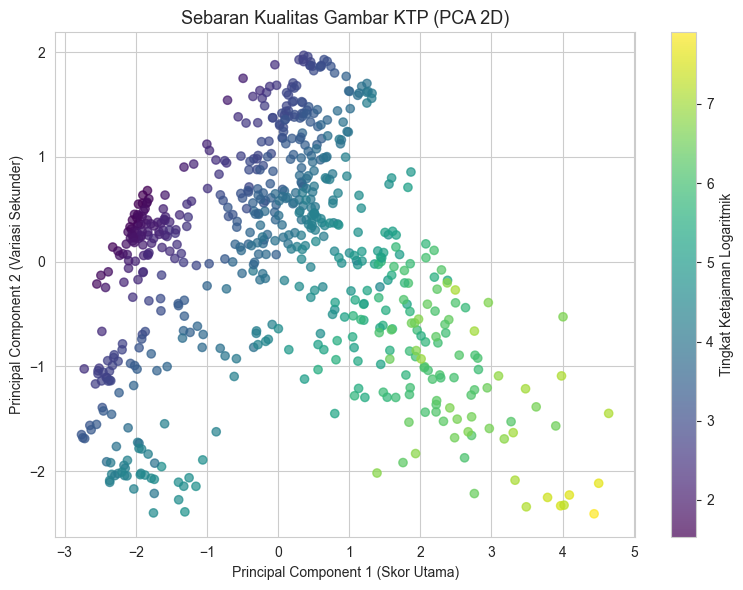

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
# Kita beri warna berdasarkan tingkat blur (kuning = tajam, ungu/gelap = buram)
scatter = ax.scatter(master_df['quality_pc1'], master_df['quality_pc2'], 
                     c=master_df['crop_blur_score_log'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Tingkat Ketajaman Logaritmik')
ax.set_title('Sebaran Kualitas Gambar KTP (PCA 2D)')
ax.set_xlabel('Principal Component 1 (Skor Utama)')
ax.set_ylabel('Principal Component 2 (Variasi Sekunder)')
plt.tight_layout()
plt.show()

## 6. Tahap Ekstraksi Teks (OCR) Dasar

Proses Ekstraksi Teks OCR.
Blok ini bertugas membaca dan menerjemahkan semua huruf dan angka yang ada di dalam gambar KTP menjadi teks digital.
Kita menurunkan resolusi gambar sebelum OCR dan memakai MKLDNN agar prosesnya berlari jauh lebih cepat dan tidak memicu lag pada komputer.

In [9]:
import pickle
RAW_OCR_CACHE = os.path.join(DATASET_DIR, 'raw_ocr_lib.pkl')
raw_ocr_results = {}

if os.path.exists(RAW_OCR_CACHE):
    with open(RAW_OCR_CACHE, 'rb') as f:
        raw_ocr_results = pickle.load(f)
        
cache_mtime = os.path.getmtime(RAW_OCR_CACHE) if os.path.exists(RAW_OCR_CACHE) else 0

print("Menjalankan OCR...")
for _, row in tqdm(master_df.iterrows(), total=len(master_df)):
    fname = row['filename']
    img_path = os.path.join(CROPPED_DIR, fname)
    if not os.path.exists(img_path):
        continue
        
    img_mtime = os.path.getmtime(img_path)
    # LOGIKA SKIP: Lewati jika gambar sudah ada di cache DAN gambar potongnya belum berubah
    if fname in raw_ocr_results and img_mtime <= cache_mtime:
        continue
        
    img = cv2.imread(img_path)
    if img is None: continue
    
    # RESIZE SEBELUM PREPROCESSING
    h, w = img.shape[:2]
    max_side = 1600
    scale = 1.0
    if max(h, w) > max_side:
        scale = max_side / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_img)
    denoised = cv2.bilateralFilter(enhanced, 9, 75, 75)
    preprocessed_img = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)
    
    # Panggil PaddleOCR
    texts, scores, boxes = parse_ocr_result(ocr_engine.ocr(preprocessed_img))
    
    # Kembalikan koordinat bounding box ke ukuran gambar aslinya
    if scale < 1.0 and boxes:
        boxes = [[[float(pt[0] / scale), float(pt[1] / scale)] for pt in box] for box in boxes]
        
    raw_ocr_results[fname] = { 'texts': texts, 'scores': scores, 'boxes': boxes }

# Simpan state OCR mentah untuk fitur "Skip"
with open(RAW_OCR_CACHE, 'wb') as f:
    pickle.dump(raw_ocr_results, f)

Menjalankan OCR...


100%|██████████| 632/632 [00:00<00:00, 3070.53it/s]


## 7. Ekstraksi Fitur Asal Dokumen

Deteksi Asal Negara KTP.
Blok ini menebak secara kasar apakah KTP ini dari Malaysia atau luar negeri berdasarkan kata kunci teks.
Kita memisahkannya menjadi fitur khusus karena tata letak KTP Malaysia dan luar negeri sangat berbeda sehingga model AI membutuhkan petunjuk awal ini.

In [10]:
def build_origin_features(texts):
    joined_text = " ".join(texts).upper()
    
    # Ekstraksi sinyal murni dan deterministik dari OCR
    has_mykad = int(any(kw in joined_text for kw in ["MYKAD", "WARGANEGARA", "KAD PENGENALAN"]))
    has_bin_binti = int(any(kw in joined_text for kw in ["BIN ", "BINTI ", "A/L ", "A/P "]))
    has_ic_pattern = int(bool(re.search(r'\b\d{12}\b|\b\d{6}-\d{2}-\d{4}\b', joined_text)))
    
    # --- PERBAIKAN REVISI KRITIK #4 & #5: EKSISI TOTAL TARGET PROXY YANG BIAS ---
    # Kita tidak lagi membuat kolom 'doc_origin_weak_label' di sini karena basis targetnya 
    # terbukti cacat secara semantik (hanya merepresentasikan kelengkapan field alamat di GT).
    # Model hilir (NB3) dipaksa bersandar pada fitur berbasis kata kunci yang eksplisit dan independen.
    
    return {
        'has_mykad_keyword': has_mykad,
        'has_ic_number_pattern': has_ic_pattern,
        'has_bin_binti_any_segment': has_bin_binti,
        'n_segments': len(texts),
        'avg_segment_len': np.mean([len(t) for t in texts]) if texts else 0
    }

origin_features_list = []
for fname, res in raw_ocr_results.items():
    feats = build_origin_features(res['texts'])
    feats['filename'] = fname
    origin_features_list.append(feats)

df_origin_feats = pd.DataFrame(origin_features_list)

# Bersihkan kolom target 'doc_origin_weak_label' yang lama dari master_df (jika ada) 
# agar tidak membawa bias/polusi data dari Tahap 1 ke pemrosesan hilir
if 'doc_origin_weak_label' in master_df.columns:
    master_df = master_df.drop(columns=['doc_origin_weak_label'])

# Gabungkan fitur-fitur independen yang baru ke master_df
master_df = master_df.merge(df_origin_feats, on='filename', how='left')

df_origin_feats.to_csv(os.path.join(DATASET_DIR, 'text_origin_features.csv'), index=False)
print("Fitur origin berhasil diperbarui. Proksi label yang bias telah dieksisi sepenuhnya.")

Fitur origin berhasil diperbarui. Proksi label yang bias telah dieksisi sepenuhnya.


## 8. Normalisasi Teks dan Ekstraksi Fitur

Ekstraksi Fitur Teks.
Blok ini menghitung rasio huruf rasio angka dan mendeteksi keberadaan pola tanggal lahir atau kodepos pada teks.
Kita butuh merangkum semua karakteristik ini agar model Machine Learning bisa menebak dengan akurat mana teks yang berisi nama dan mana teks yang sekadar instruksi cetak.

Melakukan pre-pass untuk uji sensitivitas threshold CER...


Scanning CER: 100%|██████████| 632/632 [00:00<00:00, 1483.80it/s]



Proporsi segmen yang dipertahankan sebagai 'Signal' (Bukan 'Other'):
Threshold 0.3 -> 1.45% segmen berhasil dilabeli
Threshold 0.4 -> 2.96% segmen berhasil dilabeli
Threshold 0.5 -> 4.32% segmen berhasil dilabeli


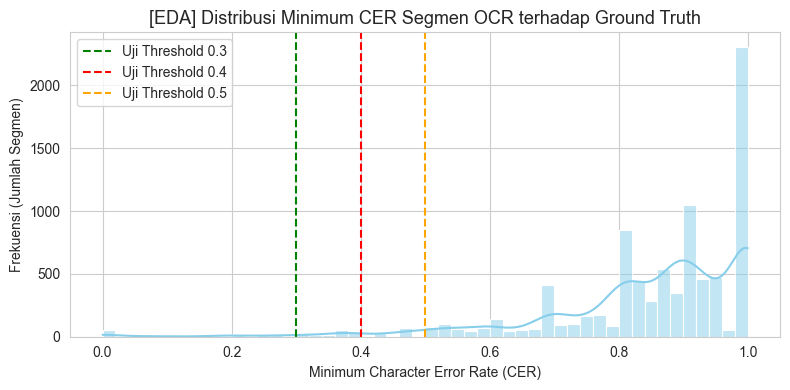

Mengekstrak fitur teks...


100%|██████████| 632/632 [04:21<00:00,  2.42it/s]


In [11]:
MALAYSIA_STATES = [
    'JOHOR','KEDAH','KELANTAN','MELAKA','NEGERI SEMBILAN','PAHANG',
    'PERAK','PERLIS','PULAU PINANG','SABAH','SARAWAK','SELANGOR',
    'TERENGGANU','KUALA LUMPUR','LABUAN','PUTRAJAYA',
    'W. PERSEKUTUAN','KL','SBH','SWK','PNG','TRG','PHG',
]
STATES_RE = re.compile('|'.join(re.escape(s) for s in MALAYSIA_STATES), re.IGNORECASE)

DATE_PATTERNS = [
    re.compile(r'\d{4}-\d{2}-\d{2}'),
    re.compile(r'\d{2}/\d{2}/\d{4}'),
    re.compile(r'\b\d{4}\b'),
]

def normalize_for_cer(text):
    text = unicodedata.normalize('NFKC', str(text))
    return text.strip().lower()

def compute_cer(hyp, ref):
    norm_hyp = normalize_for_cer(hyp)
    norm_ref = normalize_for_cer(ref)
    return lev.distance(norm_hyp, norm_ref) / max(len(norm_ref), 1)

def compute_token_overlap(seg_txt, full_gt):
    seg_tokens = str(seg_txt).upper().split()
    gt_tokens = str(full_gt).upper().split()
    if not seg_tokens or not gt_tokens: return 0.0
    
    matches = 0
    for s_tok in seg_tokens:
        for g_tok in gt_tokens:
            if lev.distance(s_tok, g_tok) <= (1 if len(s_tok) >= 4 else 0):
                matches += 1
                break
    return matches / len(seg_tokens)

def _has_date(t):     return int(any(p.search(t) for p in DATE_PATTERNS))
def _has_addr_kw(t):  return int(any(k in t.upper() for k in [
    'JALAN','JLN','LORONG','LRG','KAMPUNG','KG','NO.','NO ','TAMAN',
    'TMN','PERSIARAN','LEBUH','BATU','TINGKAT','BLOK'
]))
def _has_state(t):    return int(bool(STATES_RE.search(t.upper())))
def _has_postcode(t): return int(bool(re.search(r'\b\d{5}\b', t)))
def _has_bin(t):      return int(any(k in t.upper() for k in ['BIN ','BINTI ','A/L ','A/P ']))
def _alpha_ratio(t):  return sum(c.isalpha() for c in str(t)) / max(len(str(t)), 1)
def _digit_ratio(t):  return sum(c.isdigit() for c in str(t)) / max(len(str(t)), 1)

print("Melakukan pre-pass untuk uji sensitivitas threshold CER...")

cer_distributions = []

for _, row in tqdm(master_df.iterrows(), total=len(master_df), desc="Scanning CER"):
    fname = row['filename']
    if fname not in raw_ocr_results:
        continue
    
    texts = raw_ocr_results[fname]['texts']
    ref_addr = str(row['address']) if pd.notna(row['address']) else ''
    
    for txt in texts:
        cer_name = compute_cer(txt, str(row['name']))
        cer_dob  = compute_cer(txt, str(row['birth_date']))
        cer_addr = compute_cer(txt, ref_addr) if ref_addr else 1.0
        
        # Simpan nilai jarak terdekat (min_cer) untuk setiap potongan teks
        min_cer = min(cer_name, cer_dob, cer_addr)
        cer_distributions.append(min_cer)

df_cer_dist = pd.DataFrame({'min_cer': cer_distributions})

test_thresholds = [0.3, 0.4, 0.5]
print("\nProporsi segmen yang dipertahankan sebagai 'Signal' (Bukan 'Other'):")
for t in test_thresholds:
    signal_ratio = (df_cer_dist['min_cer'] < t).mean() * 100
    print(f"Threshold {t:.1f} -> {signal_ratio:.2f}% segmen berhasil dilabeli")

# Visualisasi Distribusi (Mencari titik lembah / valley)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_cer_dist['min_cer'], bins=50, kde=True, ax=ax, color='skyblue')
for t, color in zip(test_thresholds, ['green', 'red', 'orange']):
    ax.axvline(x=t, color=color, linestyle='--', label=f'Uji Threshold {t}')
ax.set_title('[EDA] Distribusi Minimum CER Segmen OCR terhadap Ground Truth')
ax.set_xlabel('Minimum Character Error Rate (CER)')
ax.set_ylabel('Frekuensi (Jumlah Segmen)')
ax.legend()
plt.tight_layout()
plt.show()

VALIDATED_CER_THRESHOLD = 0.4

segment_data = []

print("Mengekstrak fitur teks...")

for _, row in tqdm(master_df.iterrows(), total=len(master_df)):
    fname = row['filename']
    if fname not in raw_ocr_results:
        continue
    
    res = raw_ocr_results[fname]
    texts, scores, boxes = res['texts'], res['scores'], res['boxes']
    
    y_centers  = [float(np.mean(np.array(b)[:, 1])) for b in boxes] if boxes else []
    rank_order = {i: r for r, i in enumerate(np.argsort(y_centers))} if y_centers else {}
    ref_addr   = str(row['address']) if pd.notna(row['address']) else ''
    
    for seg_idx, (txt, conf, box) in enumerate(zip(texts, scores, boxes)):
        cer_name = compute_cer(txt, str(row['name']))
        cer_dob  = compute_cer(txt, str(row['birth_date']))
        cer_addr = compute_cer(txt, ref_addr) if ref_addr else 1.0

        min_cer = min(cer_name, cer_dob, cer_addr)
        
        # Tanggal lahir pada MyKad tergabung dalam NRIC (YYMMDD-PB-###X). Kita pakai fuzzy substring.
        overlap_dob = 0.0
        dob_gt = str(row['birth_date'])
        if len(dob_gt) >= 10:
            yymmdd = dob_gt[2:4] + dob_gt[5:7] + dob_gt[8:10]
            txt_clean = str(txt).replace('-', '').replace(' ', '')
            for i in range(max(1, len(txt_clean) - 5)):
                sub = txt_clean[i:i+6]
                if len(sub) == 6 and lev.distance(yymmdd, sub) <= 1:
                    overlap_dob = 1.0
                    break
        # Fallback jika tanggal lahir ditulis persis (CER rendah)
        if compute_cer(txt, str(row['birth_date'])) < 0.3:
            overlap_dob = 1.0

        if min_cer < VALIDATED_CER_THRESHOLD:
            label = ('name' if min_cer == cer_name else 'birth_date' if min_cer == cer_dob else 'address')
        else:
            label = 'other'
            
        pts = np.array(box)
        img_h, img_w = 1000, 1000 # Dummy fallback 
        is_spatial_dummy = 1
        img_path = os.path.join(CROPPED_DIR, fname)
        if os.path.exists(img_path):
            shape = cv2.imread(img_path).shape
            img_h, img_w = shape[0], shape[1]
            is_spatial_dummy = 0
        else:
            warnings.warn(
                f"WARNING: Gambar crop {fname} hilang! "
                "Menggunakan dimensi 1000x1000. Fitur spasial untuk dokumen ini tidak akurat."
            )

        y_rel     = float(np.mean(pts[:, 1])) / max(img_h, 1)
        x_rel     = float(np.mean(pts[:, 0])) / max(img_w, 1)
        width_rel = (float(np.max(pts[:, 0])) - float(np.min(pts[:, 0]))) / max(img_w, 1)

        segment_data.append({
            'filename':           row['filename'],
            'text':               txt,
            'ocr_conf':           float(conf),
            'y_rel':              y_rel,
            'x_rel':              x_rel,
            'width_rel':          width_rel,
            'is_spatial_dummy':   is_spatial_dummy, # Perbaikan Bug #6
            'text_len':           len(txt),
            'word_count':         len(txt.split()),
            'alpha_ratio':        _alpha_ratio(txt),
            'digit_ratio':        _digit_ratio(txt),
            'is_all_caps':        int(str(txt).isupper()),
            'has_date_pattern':   _has_date(txt),
            'has_address_kw':     _has_addr_kw(txt),
            'has_state_kw':       _has_state(txt),
            'has_postcode':       _has_postcode(txt),
            'has_bin_binti':      _has_bin(txt),
            'line_rank':          rank_order.get(seg_idx, seg_idx),
            'label':              label,
            'box':                box,
            
            # --- TRANSFORMASI FINAL (Bug #4 & #5) ---
            # doc_origin_weak_label dihapus sepenuhnya untuk mencegah polusi target bias.
            'has_mykad_keyword':     row.get('has_mykad_keyword', 0),
            'has_ic_number_pattern': row.get('has_ic_number_pattern', 0),
            
            # --- REVISI BUG #7: PEMELIHARAAN FITUR EFISIEN ---
            # quality_pc1 diwariskan karena dibutuhkan oleh TRIAGE_FEATURES.
            # quality_pc2 dihapus sepenuhnya karena merupakan dead code (tidak terpakai).
            'quality_pc1': row.get('quality_pc1', 0.0),
            'skew_angle':  row.get('skew_angle', 0.0)
        })

df_segments = pd.DataFrame(segment_data)

## 9. Analisis Kurva Quality vs CER (Kalibrasi Triage)

Kalibrasi Batas Toleransi Blur.
Blok ini menganalisis di tingkat keburaman berapa sistem OCR mulai gagal membaca nama dengan benar.
Kita melakukan perhitungan ini agar sistem produksi nantinya bisa otomatis menolak foto nasabah yang terlalu buram sebelum diproses lebih lanjut.

=== EXPLORATORY DATA ANALYSIS (EDA) TAHAP 9 ===
Estimasi Ambang batas keyakinan OCR (Subset Keseluruhan): 0.80
STATUS: Aman. Kalkulasi ini murni untuk visualisasi/EDA agar tidak menyesatkan analisa.
Ambang batas Triage untuk model final dihitung ulang secara independen per-fold di Notebook 3 (CV).


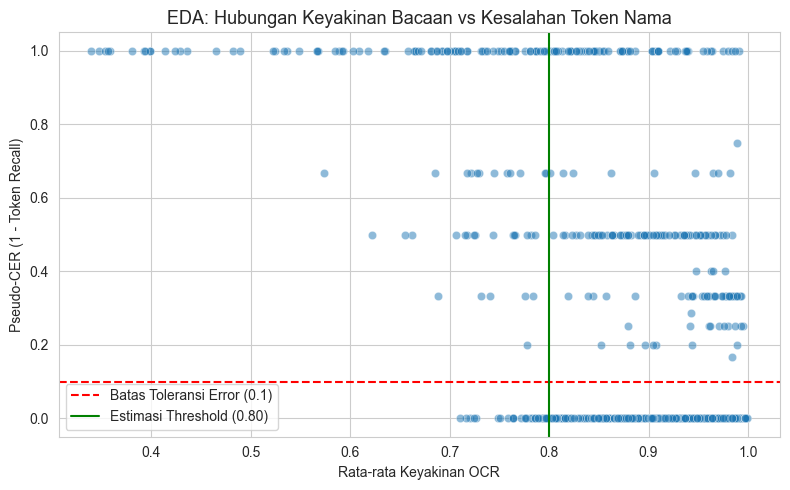

In [12]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

triage_data = []

for fname, group in df_segments.groupby('filename'):
    avg_conf = group['ocr_conf'].mean()
    row_gt = df_gt[df_gt['filename'] == fname].iloc[0]
    
    # 1. GABUNGKAN TEKS: Menyatukan seluruh segmen OCR dalam satu dokumen
    joined_ocr_text = " ".join(group['text'].astype(str))
    
    # 2. TOKEN RECALL: Memecah teks menjadi himpunan kata (set) setelah dinormalisasi
    ocr_tokens = set(normalize_for_cer(joined_ocr_text).split())
    gt_tokens = set(normalize_for_cer(str(row_gt['name'])).split())
    
    # 3. KALKULASI ERROR (EDA): Menghitung persentase kata dari Ground Truth yang ditemukan di OCR
    if len(gt_tokens) > 0:
        recall = len(gt_tokens.intersection(ocr_tokens)) / len(gt_tokens)
    else:
        recall = 0.0
        
    # Konversi recall menjadi Pseudo-CER (0.0 = Sempurna, 1.0 = Gagal Total)
    pseudo_cer_name = 1.0 - recall
            
    triage_data.append({
        'filename': fname,
        'avg_conf': avg_conf,
        'cer_name': pseudo_cer_name
    })

df_triage_curve = pd.DataFrame(triage_data)

conf_bins = np.linspace(0, 1, 11)
df_triage_curve['conf_bin'] = pd.cut(df_triage_curve['avg_conf'], bins=conf_bins)
median_cer_per_bin = df_triage_curve.groupby('conf_bin')['cer_name'].median()

# Mencegah silent failure pada visualisasi (Perbaikan Bug #2)
threshold_conf = None
for interval, med_cer in median_cer_per_bin.items():
    if pd.notna(med_cer) and med_cer <= 0.1:
        threshold_conf = interval.left
        break

if threshold_conf is None:
    fallback_threshold = 0.85
    warnings.warn(
        "EDA WARNING: Tidak ada bin keyakinan yang memenuhi syarat median_cer <= 0.1. "
        f"Visualisasi akan menggunakan batas estimasi: {fallback_threshold}"
    )
    threshold_conf = fallback_threshold

print("=== EXPLORATORY DATA ANALYSIS (EDA) TAHAP 9 ===")
print(f"Estimasi Ambang batas keyakinan OCR (Subset Keseluruhan): {threshold_conf:.2f}")
print("STATUS: Aman. Kalkulasi ini murni untuk visualisasi/EDA agar tidak menyesatkan analisa.")
print("Ambang batas Triage untuk model final dihitung ulang secara independen per-fold di Notebook 3 (CV).")

# Menyimpan nilai rata-rata OCR conf ke master dataframe untuk dipakai model nanti
master_df['avg_ocr_conf'] = master_df['filename'].map(df_triage_curve.set_index('filename')['avg_conf'])

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_triage_curve, x='avg_conf', y='cer_name', alpha=0.5, ax=ax)
ax.axhline(y=0.1, color='red', linestyle='--', label='Batas Toleransi Error (0.1)')
ax.axvline(x=threshold_conf, color='green', linestyle='-', label=f'Estimasi Threshold ({threshold_conf:.2f})')
ax.set_title('EDA: Hubungan Keyakinan Bacaan vs Kesalahan Token Nama')
ax.set_xlabel('Rata-rata Keyakinan OCR')
ax.set_ylabel('Pseudo-CER (1 - Token Recall)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Distribusi Label Segmen dan Panjang Teks

Visualisasi Distribusi Panjang Teks.
Blok ini membuat grafik untuk melihat apakah teks nama rata rata lebih panjang dari teks label lainnya.
Kita memastikannya dengan grafik agar kita tahu pasti bahwa fitur panjang teks memang bisa diandalkan untuk membedakan kategori teks.

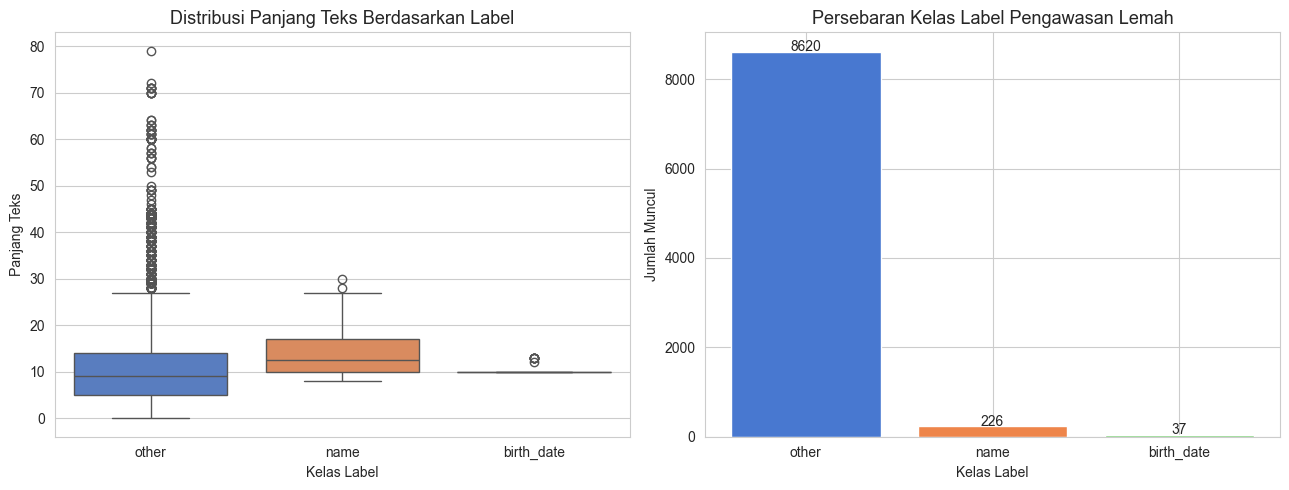

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('muted', 4)

sns.boxplot(data=df_segments, x='label', y='text_len', palette=colors, ax=axes[0])
axes[0].set_title('Distribusi Panjang Teks Berdasarkan Label')
axes[0].set_xlabel('Kelas Label')
axes[0].set_ylabel('Panjang Teks')

label_counts = df_segments['label'].value_counts()
axes[1].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Persebaran Kelas Label Pengawasan Lemah')
axes[1].set_xlabel('Kelas Label')
axes[1].set_ylabel('Jumlah Muncul')
for i, count in enumerate(label_counts.values):
    axes[1].text(i, count + 10, str(count), ha='center')

plt.tight_layout()
plt.show()

## 11. Normalisasi Spasial Akhir dan Penyimpanan

Normalisasi Skala Angka.
Blok terakhir ini bertugas meratakan semua angka koordinat lokasi agar berada di kisaran 0 sampai 1.
Kita wajib melakukan normalisasi ini karena algoritma Machine Learning akan kebingungan jika ada angka yang bernilai ribuan dicampur dengan angka desimal kecil.

In [14]:
spatial_cols = ['y_rel', 'x_rel', 'width_rel']
mm_scaler    = MinMaxScaler()
df_segments[['y_rel_scaled', 'x_rel_scaled', 'width_rel_scaled']] = \
    mm_scaler.fit_transform(df_segments[spatial_cols].fillna(0))

df_segments['line_rank_norm'] = df_segments.groupby('filename')['line_rank'].transform(
    lambda s: (s - s.min()) / max((s.max() - s.min()), 1)
)

df_segments.to_csv(os.path.join(DATASET_DIR, 'ocr_segments_features.csv'), index=False)
master_df.to_csv(MASTER_PATH, index=False)

print("Feature engineering selesai.")
print(f"Data segmen: {len(df_segments)}")
print(f"Data master: {len(master_df)}")

Feature engineering selesai.
Data segmen: 8883
Data master: 632
